In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import make_scorer, precision_score

In [2]:
path_processed = "../data/processed/"
X_train = pd.read_csv(f"{path_processed}X_train.csv")
y_train = pd.read_csv(f"{path_processed}y_train.csv").squeeze("columns")
X_test = pd.read_csv(f"{path_processed}X_test.csv")
y_test = pd.read_csv(f"{path_processed}y_test.csv").squeeze("columns")

In [3]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],          
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='precision',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [4]:
prediction = best_model.predict(X_test)

print(f"{accuracy_score(y_test, prediction) * 100:.2f}%\n")

print(classification_report(y_test, prediction))

78.94%

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       675
           1       0.71      0.66      0.69       360

    accuracy                           0.79      1035
   macro avg       0.77      0.76      0.76      1035
weighted avg       0.79      0.79      0.79      1035



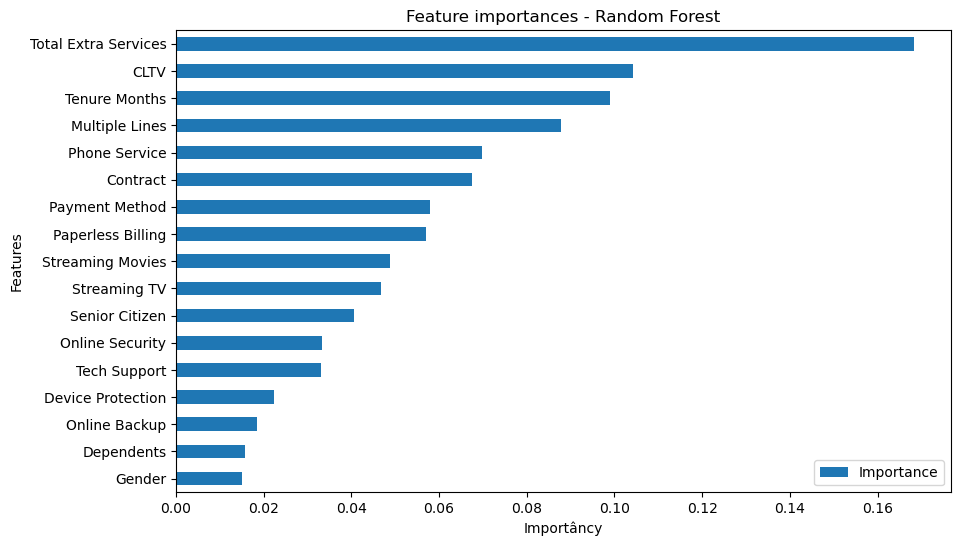

In [5]:
importances = best_model.feature_importances_
features = X_train.columns

feature_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_imp_df.head(17).plot(kind="barh", x="Feature", y="Importance", figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title("Feature importances - Random Forest")
plt.xlabel("Importâncy")
plt.ylabel("Features")
plt.show()

In [6]:
estimator = RandomForestClassifier(random_state=42, n_jobs=-1)
selector = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring="precision",
    n_jobs=-1,
    verbose=1
)

selector.fit(X_train, y_train)

best_columns = X_train.columns[selector.support_]
print(f"ideal features: {selector.n_features_}")
print(f"Columns: {list(best_columns)}")

Fitting estimator with 18 features.
ideal features: 17
Columns: ['Gender', 'Senior Citizen', 'Partner', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'CLTV', 'Total Extra Services']


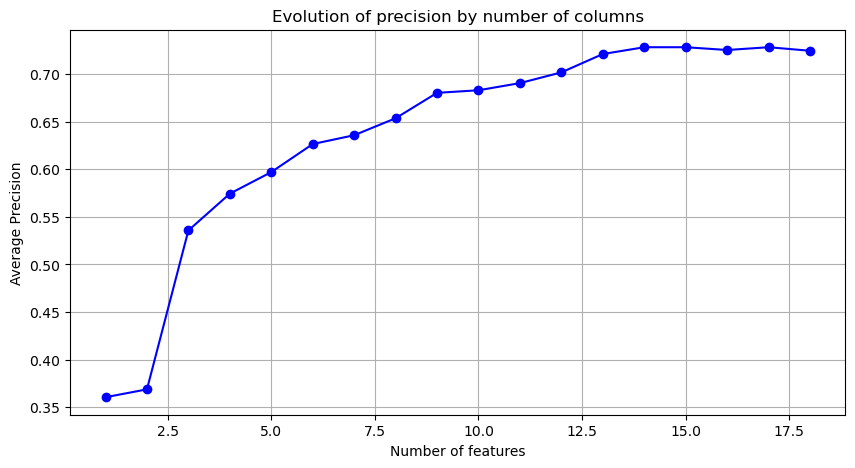

In [7]:
plt.figure(figsize=(10, 5))
plt.xlabel("Number of features")
plt.ylabel("Average Precision")

importances_history = selector.cv_results_['mean_test_score']
plt.plot(range(1, len(importances_history) + 1), importances_history, marker='o', color='b')

plt.title("Evolution of precision by number of columns")
plt.grid(True)
plt.show()

In [8]:
rfe_ranking = RFE(
    estimator=estimator,
    n_features_to_select=1,
    step=1
)

rfe_ranking.fit(X_train, y_train)

table_ranking = pd.DataFrame({
    'Column': X_train.columns,
    'Rank': rfe_ranking.ranking_
}).sort_values(by='Rank')

top13_columns = table_ranking['Column'].head(13).tolist()
top13_columns

['CLTV',
 'Tenure Months',
 'Total Extra Services',
 'Payment Method',
 'Multiple Lines',
 'Contract',
 'Streaming TV',
 'Phone Service',
 'Paperless Billing',
 'Streaming Movies',
 'Senior Citizen',
 'Tech Support',
 'Online Security']

In [9]:
scorer_precision = make_scorer(precision_score, zero_division=0)
sfs = SequentialFeatureSelector(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    n_features_to_select=13,
    direction='forward',
    scoring=scorer_precision,
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train, y_train)
sfs_columns = X_train.columns[sfs.get_support()]
print(list(sfs_columns))

['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Extra Services']


In [10]:
print(len(set(sfs_columns + top13_columns)))

13


In [11]:
X_test_opt = X_test[top13_columns]
X_train_opt = X_train[top13_columns]

opt_model = RandomForestClassifier(random_state=42, n_jobs=-1)

opt_model.fit(X_train_opt, y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
prediction = opt_model.predict(X_test_opt)

print(f"{accuracy_score(y_test, prediction) * 100:.2f}%\n")

print(classification_report(y_test, prediction))

78.74%

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       675
           1       0.70      0.68      0.69       360

    accuracy                           0.79      1035
   macro avg       0.77      0.76      0.76      1035
weighted avg       0.79      0.79      0.79      1035



In [13]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],          
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='precision',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_opt, y_train)

best_model_opt = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [14]:
prediction = best_model_opt.predict(X_test_opt)

print(f"{accuracy_score(y_test, prediction) * 100:.2f}%\n")

print(classification_report(y_test, prediction))

80.19%

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       675
           1       0.73      0.69      0.71       360

    accuracy                           0.80      1035
   macro avg       0.78      0.78      0.78      1035
weighted avg       0.80      0.80      0.80      1035



In [17]:
joblib.dump(best_model_opt, '../models/random_forest_final.pkl')

['../models/random_forest_final.pkl']